## Finding Top Stock keeping unit (according to order volume)

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


In [3]:
from api.database import engine
from sqlalchemy import text
import pandas as pd

query = text("""
SELECT sku_id, COUNT(*) as order_count, SUM(quantity) as total_quantity
FROM orders
GROUP BY sku_id
ORDER BY order_count DESC
LIMIT 10;
""")

with engine.connect() as conn:
    top_skus = pd.read_sql(query, conn)

top_skus

,sku_id,order_count,total_quantity
0,4382,52,450
1,1951,52,64
2,939,51,305
3,3778,50,1518
4,2084,50,444
5,1477,50,305
6,899,48,828
7,1189,48,318
8,3308,48,116
9,2756,48,269


## Daily time series of SKU

In [4]:
sku_id = 4382

query2 = f"""
SELECT 
    order_date::date AS ds,
    SUM(quantity) AS y
FROM orders
WHERE sku_id = '{sku_id}'
GROUP BY order_date::date
ORDER BY ds;
"""

demand_series = pd.read_sql(query2, engine)
demand_series

,ds,y
0,2023-01-28,7
1,2023-01-29,10
2,2023-02-22,15
3,2023-04-08,6
4,2023-04-16,10
5,2023-04-23,8
6,2023-07-10,5
7,2023-08-12,7
8,2023-08-30,9
9,2023-09-07,4


In [5]:
query3 = """
SELECT 
    order_date::date AS ds,
    SUM(quantity) AS y
FROM orders
GROUP BY order_date::date
ORDER BY ds;
"""

overall_demand = pd.read_sql(query3, engine)
overall_demand.shape

(1096, 2)

### Plotting seasonal pattern

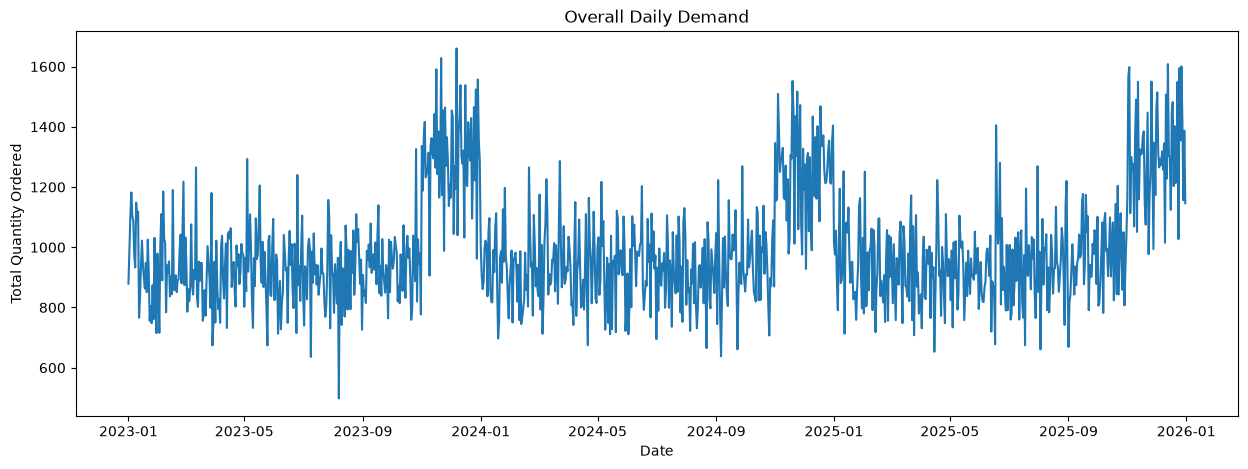

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(overall_demand['ds'], overall_demand['y'])
plt.title("Overall Daily Demand")
plt.xlabel("Date")
plt.ylabel("Total Quantity Ordered")
plt.show()

In [7]:
from prophet import Prophet

model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(overall_demand)

c:\Users\PMLS\anaconda3\envs\supplychain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
14:06:03 - cmdstanpy - INFO - Chain [1] start processing
14:06:05 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
# Create future dataframe — 30 days ahead
future = model.make_future_dataframe(periods=30)

# Generate forecast
forecast = model.predict(future)

# Look at the last few predicted rows
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1121,2026-01-26,933.374251,777.512061,1089.887866
1122,2026-01-27,958.423296,787.508613,1125.480525
1123,2026-01-28,950.472624,785.022669,1123.057563
1124,2026-01-29,937.761782,764.195016,1103.820292
1125,2026-01-30,953.341681,794.907562,1112.418086


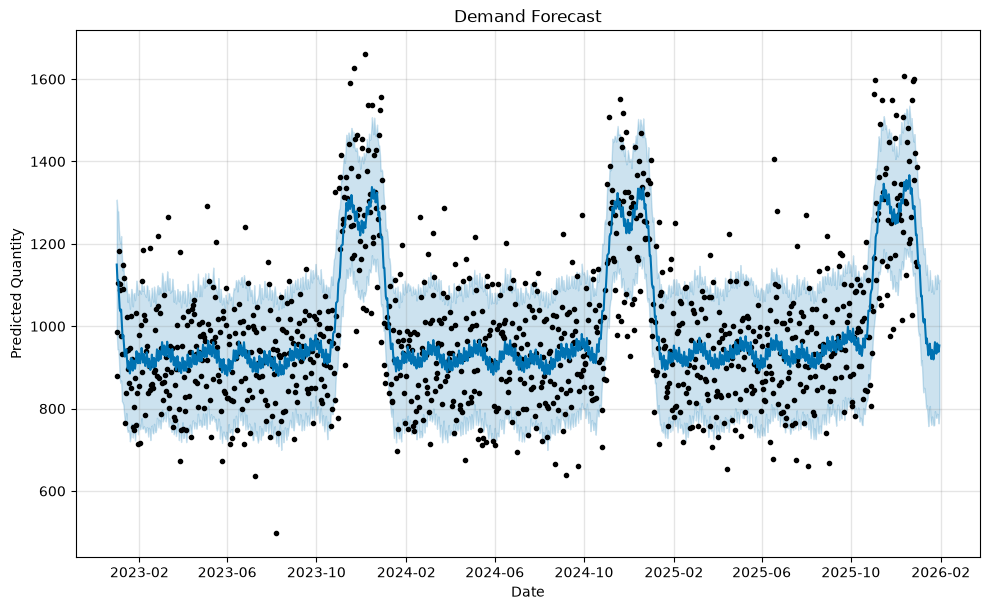

In [9]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title("Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Quantity")
plt.show()

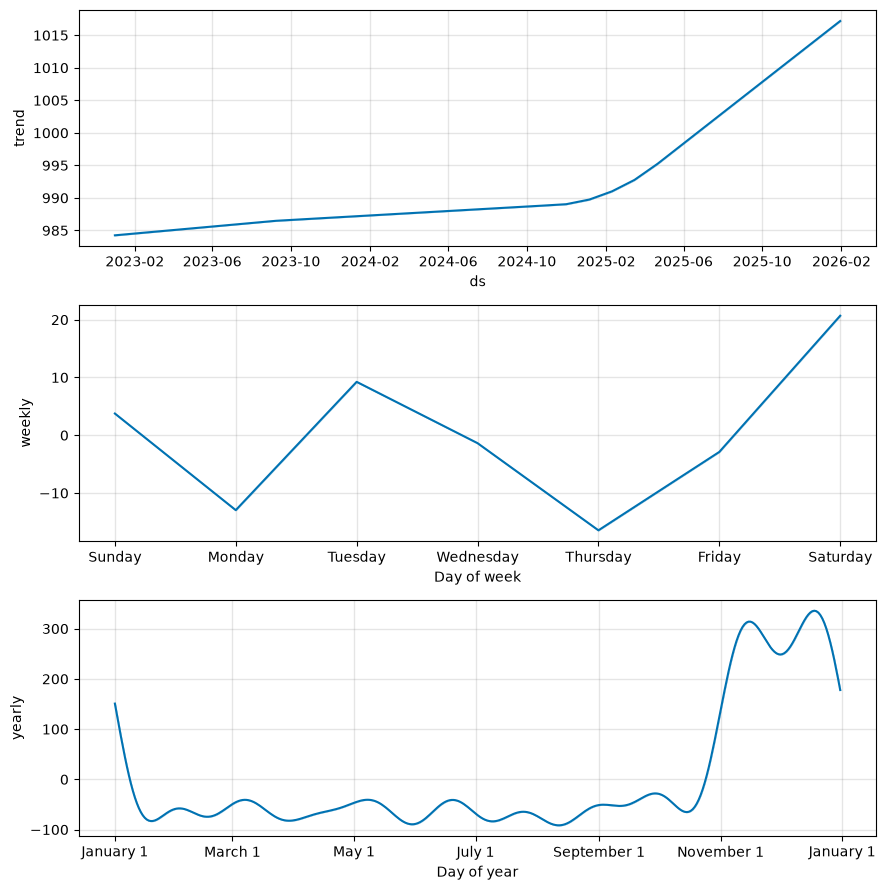

In [10]:
# Plot trend and seasonality components separately
fig2 = model.plot_components(forecast)
plt.show()

In [12]:
# Train/test split — hold out the last 90 days as test set
train = overall_demand[overall_demand['ds'] < overall_demand['ds'].max() - pd.Timedelta(days=90)]
test = overall_demand[overall_demand['ds'] >= overall_demand['ds'].max() - pd.Timedelta(days=90)]

print(f"Train size: {len(train)}, Test size: {len(test)}")

# Train a fresh model only on the train set
model_eval = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_eval.fit(train)

# Forecast for the test period
future_eval = model_eval.make_future_dataframe(periods=90)
forecast_eval = model_eval.predict(future_eval)

# Ensure both 'ds' columns are the same datetime type before merging
test = test.copy()
test['ds'] = pd.to_datetime(test['ds'])
forecast_eval['ds'] = pd.to_datetime(forecast_eval['ds'])

# Merge predictions with actual test values
results = test.merge(forecast_eval[['ds', 'yhat']], on='ds', how='left')
results.head()

Train size: 1005, Test size: 91


14:28:48 - cmdstanpy - INFO - Chain [1] start processing
14:28:48 - cmdstanpy - INFO - Chain [1] done processing


,ds,y,yhat
0,2025-10-02,806,950.950640
1,2025-10-03,816,966.599895
2,2025-10-04,883,980.770100
3,2025-10-05,973,962.402708
4,2025-10-06,1082,935.809441


In [14]:
# Check for missing values
print(results.isna().sum())
results[results.isna().any(axis=1)]

ds      0
y       0
yhat    1
dtype: int64


,ds,y,yhat
90,2025-12-31,1146,NaN


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Drop the one row with missing forecast (boundary date beyond forecast range)
results_clean = results.dropna(subset=['y', 'yhat'])

print(f"Rows before cleaning: {len(results)}, after: {len(results_clean)}")

mae = mean_absolute_error(results_clean['y'], results_clean['yhat'])
rmse = np.sqrt(mean_squared_error(results_clean['y'], results_clean['yhat']))
r2 = r2_score(results_clean['y'], results_clean['yhat'])

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

Rows before cleaning: 91, after: 90
MAE: 130.02
RMSE: 164.77
R²: 0.4323


In [18]:
# Try multiplicative seasonality — better for spikes that scale with the baseline
model_eval2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
model_eval2.fit(train)

future_eval2 = model_eval2.make_future_dataframe(periods=90)
forecast_eval2 = model_eval2.predict(future_eval2)

forecast_eval2['ds'] = pd.to_datetime(forecast_eval2['ds'])
results2 = test.merge(forecast_eval2[['ds', 'yhat']], on='ds', how='left')
results2_clean = results2.dropna(subset=['y', 'yhat'])

mae2 = mean_absolute_error(results2_clean['y'], results2_clean['yhat'])
rmse2 = np.sqrt(mean_squared_error(results2_clean['y'], results2_clean['yhat']))
r2_2 = r2_score(results2_clean['y'], results2_clean['yhat'])

print(f"MAE: {mae2:.2f}")
print(f"RMSE: {rmse2:.2f}")
print(f"R²: {r2_2:.4f}")

14:34:03 - cmdstanpy - INFO - Chain [1] start processing
14:34:03 - cmdstanpy - INFO - Chain [1] done processing


MAE: 129.76
RMSE: 164.42
R²: 0.4347


In [19]:
# Prepare data for LightGBM — feature engineering
df = overall_demand.copy()
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds').reset_index(drop=True)

# Time-based features
df['day_of_week'] = df['ds'].dt.dayofweek
df['month'] = df['ds'].dt.month
df['day_of_year'] = df['ds'].dt.dayofyear
df['year'] = df['ds'].dt.year

# Lag features (previous demand values)
df['y_lag_1'] = df['y'].shift(1)
df['y_lag_7'] = df['y'].shift(7)
df['y_lag_30'] = df['y'].shift(30)

# Rolling averages
df['y_rolling_7'] = df['y'].shift(1).rolling(window=7).mean()
df['y_rolling_30'] = df['y'].shift(1).rolling(window=30).mean()

# Drop rows with NaN from lag/rolling features
df = df.dropna().reset_index(drop=True)

df.head()

,ds,y,day_of_week,month,day_of_year,year,y_lag_1,y_lag_7,y_lag_30,y_rolling_7,y_rolling_30
0,2023-01-31,979,1,1,31,2023,715.0,805.0,879.0,824.571429,938.366667
1,2023-02-01,856,2,2,32,2023,979.0,748.0,987.0,849.428571,941.700000
2,2023-02-02,716,3,2,33,2023,856.0,874.0,1106.0,864.857143,937.333333
3,2023-02-03,1003,4,2,34,2023,716.0,761.0,1182.0,842.285714,924.333333
4,2023-02-04,1110,5,2,35,2023,1003.0,1031.0,1103.0,876.857143,918.366667


In [20]:
from lightgbm import LGBMRegressor

# Feature columns and target
feature_cols = ['day_of_week', 'month', 'day_of_year', 'year',
                 'y_lag_1', 'y_lag_7', 'y_lag_30', 'y_rolling_7', 'y_rolling_30']

# Time-based split — last 90 days as test (same as Prophet split)
split_date = df['ds'].max() - pd.Timedelta(days=90)

train_lgb = df[df['ds'] < split_date]
test_lgb = df[df['ds'] >= split_date]

X_train, y_train = train_lgb[feature_cols], train_lgb['y']
X_test, y_test = test_lgb[feature_cols], test_lgb['y']

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Train LightGBM
lgb_model = LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)

# Predict
y_pred = lgb_model.predict(X_test)

Train size: 975, Test size: 91
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1554
[LightGBM] [Info] Number of data points in the train set: 975, number of used features: 9
[LightGBM] [Info] Start training from score 974.395897


In [21]:
mae_lgb = mean_absolute_error(y_test, y_pred)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lgb = r2_score(y_test, y_pred)

print(f"LightGBM — MAE: {mae_lgb:.2f}")
print(f"LightGBM — RMSE: {rmse_lgb:.2f}")
print(f"LightGBM — R²: {r2_lgb:.4f}")

LightGBM — MAE: 138.17
LightGBM — RMSE: 166.07
LightGBM — R²: 0.4172


In [22]:
# Check which features the model relied on most
import pandas as pd

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
7,y_rolling_7,491
5,y_lag_7,489
6,y_lag_30,469
4,y_lag_1,457
8,y_rolling_30,434
2,day_of_year,397
0,day_of_week,137
3,year,70
1,month,56


In [23]:
# Add yearly lag feature to directly capture seasonal repetition
df = overall_demand.copy()
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds').reset_index(drop=True)

# Time-based features
df['day_of_week'] = df['ds'].dt.dayofweek
df['month'] = df['ds'].dt.month
df['day_of_year'] = df['ds'].dt.dayofyear
df['year'] = df['ds'].dt.year

# Lag features
df['y_lag_1'] = df['y'].shift(1)
df['y_lag_7'] = df['y'].shift(7)
df['y_lag_30'] = df['y'].shift(30)
df['y_lag_365'] = df['y'].shift(365)   # same day, previous year

# Rolling averages
df['y_rolling_7'] = df['y'].shift(1).rolling(window=7).mean()
df['y_rolling_30'] = df['y'].shift(1).rolling(window=30).mean()

df = df.dropna().reset_index(drop=True)
print(df.shape)
df.head()

(731, 12)


,ds,y,day_of_week,month,day_of_year,year,y_lag_1,y_lag_7,y_lag_30,y_lag_365,y_rolling_7,y_rolling_30
0,2024-01-01,1008,0,1,1,2024,1289.0,1465.0,1454.0,879.0,1339.285714,1317.333333
1,2024-01-02,906,1,1,2,2024,1008.0,1222.0,1433.0,987.0,1274.000000,1302.466667
2,2024-01-03,861,2,1,3,2024,906.0,1524.0,1044.0,1106.0,1228.857143,1284.900000
3,2024-01-04,885,3,1,4,2024,861.0,962.0,1269.0,1182.0,1134.142857,1278.800000
4,2024-01-05,999,4,1,5,2024,885.0,1557.0,1194.0,1103.0,1123.142857,1266.000000


In [24]:
# Retrain LightGBM with yearly lag feature included
feature_cols = ['day_of_week', 'month', 'day_of_year', 'year',
                 'y_lag_1', 'y_lag_7', 'y_lag_30', 'y_lag_365',
                 'y_rolling_7', 'y_rolling_30']

split_date = df['ds'].max() - pd.Timedelta(days=90)

train_lgb = df[df['ds'] < split_date]
test_lgb = df[df['ds'] >= split_date]

X_train, y_train = train_lgb[feature_cols], train_lgb['y']
X_test, y_test = test_lgb[feature_cols], test_lgb['y']

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

lgb_model = LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)

y_pred = lgb_model.predict(X_test)

mae_lgb2 = mean_absolute_error(y_test, y_pred)
rmse_lgb2 = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lgb2 = r2_score(y_test, y_pred)

print(f"LightGBM (with yearly lag) — MAE: {mae_lgb2:.2f}")
print(f"LightGBM (with yearly lag) — RMSE: {rmse_lgb2:.2f}")
print(f"LightGBM (with yearly lag) — R²: {r2_lgb2:.4f}")

Train size: 640, Test size: 91
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1519
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 10
[LightGBM] [Info] Start training from score 964.034375
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

In [25]:
# Tune LightGBM for a smaller dataset
lgb_model2 = LGBMRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=15,          # smaller trees — less prone to no-split warnings
    min_child_samples=10,   # allow smaller leaf groups given limited data
    max_depth=5
)
lgb_model2.fit(X_train, y_train)

y_pred2 = lgb_model2.predict(X_test)

mae_lgb3 = mean_absolute_error(y_test, y_pred2)
rmse_lgb3 = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_lgb3 = r2_score(y_test, y_pred2)

print(f"LightGBM (tuned) — MAE: {mae_lgb3:.2f}")
print(f"LightGBM (tuned) — RMSE: {rmse_lgb3:.2f}")
print(f"LightGBM (tuned) — R²: {r2_lgb3:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000557 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1519
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 10
[LightGBM] [Info] Start training from score 964.034375
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [28]:
import joblib

# Retrain the final model on the FULL dataset (not just train split) for production use
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
final_model.fit(overall_demand)
# Ensure the models folder exists
os.makedirs('../models', exist_ok=True)

# Save to models/ folder
joblib.dump(final_model, '../models/prophet_demand_model.pkl')
print("Model saved.")

14:55:55 - cmdstanpy - INFO - Chain [1] start processing
14:55:55 - cmdstanpy - INFO - Chain [1] done processing


Model saved.


In [29]:
import pickle
print(pickle.__file__)
with open("models/prophet_demand_model.pkl", "wb") as f:
    pickle.dump(model, f)

c:\Users\PMLS\anaconda3\envs\supplychain\Lib\pickle.py


FileNotFoundError: [Errno 2] No such file or directory: 'models/prophet_demand_model.pkl'

In [30]:
import os
print(os.getcwd())

e:\Ai SUpply Chain\notebooks


In [32]:
import joblib
joblib.dump(model, "models/prophet_demand_model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'models/prophet_demand_model.pkl'

In [33]:
import os
print(os.path.exists("models"))
print(os.path.exists("../models"))

False
True


In [34]:
!findstr /i "dump save pickle joblib" notebooks\forecasting_exploration.ipynb

FINDSTR: Cannot open notebooks\forecasting_exploration.ipynb


In [35]:
with open("forecasting_exploration.ipynb", "r", encoding="utf-8") as f:
    content = f.read()

for i, line in enumerate(content.splitlines()):
    if any(kw in line.lower() for kw in ["dump", "pickle", "joblib", ".pkl"]):
        print(i, line)

1928     "import joblib\n",
1942     "joblib.dump(final_model, '../models/prophet_demand_model.pkl')\n",
1956       "c:\\Users\\PMLS\\anaconda3\\envs\\supplychain\\Lib\\pickle.py\n"
1961      "evalue": "[Errno 2] No such file or directory: 'models/prophet_demand_model.pkl'",
1966       "\u001bCell\u001b\u001b \u001b\u001bIn[29]\u001b\u001b, line 3\u001b\n\u001b      1\u001b \u001bimport\u001b pickle\n\u001b      2\u001b print(pickle.__file__)\n\u001b----> \u001b\u001b3\u001b \u001bwith\u001b open(\u001b\"models/prophet_demand_model.pkl\"\u001b, \u001b\"wb\"\u001b) \u001bas\u001b f:\n\u001b      4\u001b     pickle.dump(model, f)\n",
1967       "\u001bFileNotFoundError\u001b: [Errno 2] No such file or directory: 'models/prophet_demand_model.pkl'"
1972     "import pickle\n",
1973     "print(pickle.__file__)\n",
1974     "with open(\"models/prophet_demand_model.pkl\", \"wb\") as f:\n",
1975     "    pickle.dump(model, f)"
2005      "evalue": "[Errno 2] No such file or directory: 'models/pr